### 차트 작성 시 한글 깨짐 방지를 위한 koreanize-matplotlib 설치

In [47]:
!pip install koreanize-matplotlib

### 라이브러리 import

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

### 1. 데이터 로드 및 확인

In [3]:
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
feature_names = diabetes.feature_names

In [4]:
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
display(df.head())

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [5]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


None

### 2. 데이터 전처리: 분포 확인 및 변환

Text(0.5, 0, '당뇨병 진행도')

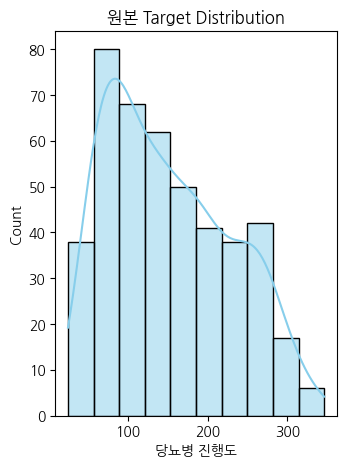

In [6]:
plt.figure(figsize=(8, 5))

# 타겟 변수의 분포 확인
plt.subplot(1, 2, 1)
sns.histplot(y, kde=True, color='skyblue')
plt.title("원본 Target Distribution")
plt.xlabel("당뇨병 진행도")

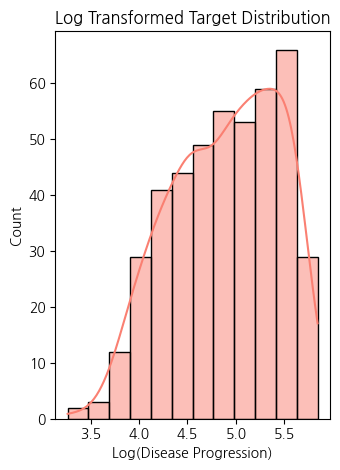

In [7]:
# (참고) 로그 변환 적용 시 분포 변화 확인
y_log = np.log1p(y)

plt.subplot(1, 2, 2)
sns.histplot(y_log, kde=True, color='salmon')
plt.title("Log Transformed Target Distribution")
plt.xlabel("Log(Disease Progression)")

plt.tight_layout()
plt.show()

### 3. 데이터 분할

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((353, 10), (89, 10), (353,), (89,))

### 4. 선형 회귀 모델 학습

In [9]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 5. 예측 및 평가
#### 평가 지표: MSE (평균 제곱 오차), RMSE (평균 제곱근 오차)

In [10]:
y_preds = lr.predict(X_test)

mse = mean_squared_error(y_test, y_preds)
rmse = np.sqrt(mse)

print(f"MSE (Mean Squared Error): {mse:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")

MSE (Mean Squared Error): 2900.19
RMSE (Root Mean Squared Error): 53.85


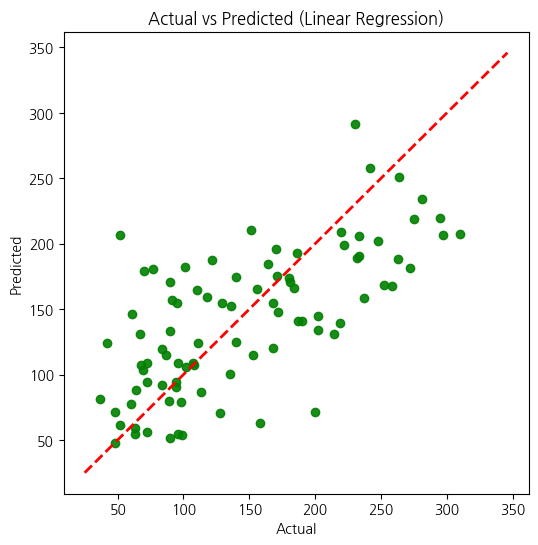

In [17]:
# (시각화) 실제값 vs 예측값 비교
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_preds, alpha=0.9, color='green')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # 대각선 (완벽한 예측선)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

### 6. 결과 해석: 회귀 계수

In [12]:
print(f"절편 (Intercept): {np.round(lr.intercept_, 2)}")

# 회귀 계수를 Series로 만들어 정렬하여 출력
coef_series = pd.Series(data=np.round(lr.coef_, 2), index=feature_names)
coef_series = coef_series.sort_values(ascending=False)

print("\n[Feature별 회귀 계수 (영향력 순)]")
print(coef_series)

print("\n[해석 예시]")
top_feature = coef_series.index[0]
top_coef = coef_series.iloc[0]
print(f"- 가장 양의 영향력이 큰 변수: {top_feature} (계수: {top_coef})")
print(f"  -> {top_feature} 수치가 높을수록 당뇨병 진행도가 증가하는 경향이 있음.")

절편 (Intercept): 151.35

[Feature별 회귀 계수 (영향력 순)]
s5     736.20
bmi    542.43
s2     518.06
bp     347.70
s4     275.32
s3     163.42
s6      48.67
age     37.90
sex   -241.96
s1    -931.49
dtype: float64

[해석 예시]
- 가장 양의 영향력이 큰 변수: s5 (계수: 736.2)
  -> s5 수치가 높을수록 당뇨병 진행도가 증가하는 경향이 있음.
